# Audit Technique et Ethique
## Adult Dataset -- Prediction de revenu (>50K / <=50K)

---

### Objectif du notebook

Ce notebook realise un **double audit** d un modele de classification (Random Forest)
entraine sur le *Adult Census Income Dataset* (UCI) :

| Dimension | Questions posees |
|-----------|-----------------|
| **Technique** | Le code est-il bien concu ? Le modele est-il correctement evalue ? |
| **Ethique** | Le modele discrimine-t-il selon le sexe, la race ou l age ? |

### Plan

| # | Section | Contenu |
|---|---------|---------|
| **0** | Dependances | Imports et constantes |
| **1** | **Audit du programme source** | Analyse statique de main.py : carte des fonctions, problemes techniques et ethiques identifies dans le code |
| **2** | Chargement & exploration (EDA) | Distribution cible, valeurs manquantes, variables numeriques, attributs sensibles |
| **3** | Audit du pipeline | Data leakage, suppression NaN, encodage, points critiques |
| **4** | Performance globale | Accuracy, AUC, F1-macro, matrice de confusion, courbes ROC et PR, courbe d apprentissage |
| **5** | Features importances | MDI vs permutation, poids des attributs sensibles |
| **6** | Audit ethique | Demographic Parity, Disparate Impact (regle 4/5), Equalized Odds, calibration par groupe |
| **7** | Synthese & recommandations | Tableau de bord, plan d action priorise |

---
## 0. Dépendances

In [6]:
import warnings
warnings.filterwarnings('ignore')

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from sklearn.inspection import permutation_importance

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Chemins
DATA_PATH  = os.path.join('data', 'adult.csv')
MODEL_PATH = os.path.join('artifacts', 'model.joblib')

# Colonnes (reprises depuis main.py)
TARGET_COL       = 'income'
NUMERIC_COLS     = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']
CATEGORICAL_COLS = ['workclass','education','marital.status','occupation','relationship',
                    'race','sex','native.country']
SENSITIVE_COLS   = ['sex', 'race']  # attributs sensibles pour l'audit éthique

print('Packages chargés ✓')

Packages chargés ✓


---
## 1. Audit du Programme Source — `main.py`

Avant d'analyser les données ou le modèle, on audite le **code lui-même** :
quels choix de conception ont été faits, et quels problèmes sont visibles
à la simple lecture du programme ?

In [7]:
# Affichage du code source de main.py
with open('../Richness_Predictor/main.py', encoding='utf-8') as f:
    src = f.read()
print(src)


import os
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib


DATA_PATH = os.path.join("data", "adult.csv")
MODEL_PATH = os.path.join("artifacts", "model.joblib")

TARGET_COL = "income"

CATEGORICAL_COLS = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",       
    "sex",          
    "native.country"
]

NUMERIC_COLS = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]


def load_data(csv_path: str) -> pd.DataFrame:

    df = pd.read_csv(csv_path)
    return df


def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    df.replace(" ?", np.nan, inplace=True)
    df.dropna(inplace=True)
    return df


def prepare_features(df: pd.DataFrame):

    X = df[NUMERIC_COLS

### 1.1 Carte des fonctions

In [8]:
import ast

with open('../Richness_Predictor/main.py', encoding='utf-8') as f:
    tree = ast.parse(f.read())

fonctions = {
    'load_data'        : 'Lecture CSV brut',
    'data_cleaning'    : 'Remplacement ? -> NaN + dropna',
    'prepare_features' : 'Encodage + separation X/y',
    'train_model'      : 'Entrainement RandomForest',
    'evaluate_model'   : 'Accuracy + classification_report',
    'save_model'       : 'Serialisation joblib',
    'load_model'       : 'Deserialisation joblib',
    'simple_inference' : 'Prediction sur nouvelles donnees',
    'main'             : 'Orchestration complete',
}

print(f'{"Fonction":<25} {"Lignes":>8}  Responsabilite')
print('-' * 68)
for node in ast.walk(tree):
    if isinstance(node, ast.FunctionDef):
        n = node.end_lineno - node.lineno + 1
        print(f'  {node.name:<23} {n:>5} lignes  {fonctions.get(node.name, "—")}')

Fonction                    Lignes  Responsabilite
--------------------------------------------------------------------
  load_data                   4 lignes  Lecture CSV brut
  data_cleaning               6 lignes  Remplacement ? -> NaN + dropna
  prepare_features           11 lignes  Encodage + separation X/y
  train_model                10 lignes  Entrainement RandomForest
  evaluate_model              8 lignes  Accuracy + classification_report
  save_model                  9 lignes  Serialisation joblib
  load_model                  5 lignes  Deserialisation joblib
  simple_inference            7 lignes  Prediction sur nouvelles donnees
  main                       34 lignes  Orchestration complete


### 1.2 Problèmes techniques identifiés dans le code

In [9]:
import pandas as pd

problemes_tech = [
    {
        'N': 1,
        'Localisation': 'data_cleaning()\nL.45-50',
        'Probleme': 'Suppression silencieuse des NaN',
        'Impact': 'Perte de 7% des donnees. Profil des individus exclus jamais verifie -> biais de selection potentiel.',
        'Correction': "Imputer avec SimpleImputer(strategy='most_frequent') pour les colonnes categoriques."
    },
    {
        'N': 2,
        'Localisation': 'prepare_features()\nL.53-63',
        'Probleme': 'get_dummies applique AVANT le split train/test',
        'Impact': "Data leakage leger : categories rares du test influencent l'encodage global.",
        'Correction': 'Pipeline sklearn avec ColumnTransformer + OneHotEncoder(handle_unknown="ignore").'
    },
    {
        'N': 3,
        'Localisation': 'prepare_features()\nL.55',
        'Probleme': 'fnlwgt inclus comme feature predictive',
        'Impact': "fnlwgt est un poids de recensement, pas une caracteristique individuelle. Fausse les importances.",
        'Correction': "Retirer fnlwgt de NUMERIC_COLS ou l'utiliser comme sample_weight dans model.fit()."
    },
    {
        'N': 4,
        'Localisation': 'train_model()\nL.66-75',
        'Probleme': "Pas de validation croisee ni recherche d'hyperparametres",
        'Impact': 'max_depth=None = arbres entierement developpes -> surapprentissage possible.',
        'Correction': 'GridSearchCV ou RandomizedSearchCV sur max_depth, min_samples_leaf, n_estimators.'
    },
    {
        'N': 5,
        'Localisation': 'evaluate_model()\nL.78-85',
        'Probleme': 'Evaluation limitee : accuracy + classification_report seulement',
        'Impact': "Avec 75/25 de desequilibre, l'accuracy est trompeuse. Pas de ROC-AUC ni courbe PR.",
        'Correction': 'Ajouter roc_auc_score, average_precision_score, ConfusionMatrixDisplay.'
    },
    {
        'N': 6,
        'Localisation': 'simple_inference()\nL.106-112',
        'Probleme': 'Re-encodage get_dummies a l inference sans garantie de coherence',
        'Impact': 'Si une categorie absente a l entrainement apparait en production, les colonnes divergent en silence.',
        'Correction': 'Sauvegarder le preprocesseur sklearn et appeler preprocessor.transform() a l inference.'
    },
]

df_tech = pd.DataFrame(problemes_tech).set_index('N')

(df_tech.style
    .set_properties(**{
        'white-space':    'pre-wrap',
        'text-align':     'left',
        'vertical-align': 'top',
        'font-size':      '12px',
    })
    .set_properties(subset=['Localisation'], **{'font-family': 'monospace', 'width': '130px'})
    .set_properties(subset=['Probleme'],     **{'font-weight': 'bold',      'width': '200px'})
    .set_properties(subset=['Impact'],       **{'color': '#7f0000',         'width': '300px'})
    .set_properties(subset=['Correction'],   **{'color': '#155724',         'width': '300px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'), ('color', 'white'),
                  ('font-size', '12px'), ('text-align', 'center')]
    }])
)

,Localisation,Probleme,Impact,Correction
N,,,,
1,data_cleaning() L.45-50,Suppression silencieuse des NaN,Perte de 7% des donnees. Profil des individus exclus jamais verifie -> biais de selection potentiel.,Imputer avec SimpleImputer(strategy='most_frequent') pour les colonnes categoriques.
2,prepare_features() L.53-63,get_dummies applique AVANT le split train/test,Data leakage leger : categories rares du test influencent l'encodage global.,"Pipeline sklearn avec ColumnTransformer + OneHotEncoder(handle_unknown=""ignore"")."
3,prepare_features() L.55,fnlwgt inclus comme feature predictive,"fnlwgt est un poids de recensement, pas une caracteristique individuelle. Fausse les importances.",Retirer fnlwgt de NUMERIC_COLS ou l'utiliser comme sample_weight dans model.fit().
4,train_model() L.66-75,Pas de validation croisee ni recherche d'hyperparametres,max_depth=None = arbres entierement developpes -> surapprentissage possible.,"GridSearchCV ou RandomizedSearchCV sur max_depth, min_samples_leaf, n_estimators."
5,evaluate_model() L.78-85,Evaluation limitee : accuracy + classification_report seulement,"Avec 75/25 de desequilibre, l'accuracy est trompeuse. Pas de ROC-AUC ni courbe PR.","Ajouter roc_auc_score, average_precision_score, ConfusionMatrixDisplay."
6,simple_inference() L.106-112,Re-encodage get_dummies a l inference sans garantie de coherence,"Si une categorie absente a l entrainement apparait en production, les colonnes divergent en silence.",Sauvegarder le preprocesseur sklearn et appeler preprocessor.transform() a l inference.


### 1.3 Problèmes éthiques identifiés dans le code

In [10]:
problemes_ethiques = [
    {
        'Localisation': 'main.py L.18-26 (CATEGORICAL_COLS)',
        'Probleme': 'Attributs sensibles race et sex inclus dans les features',
        'Impact': 'Le modele apprend et perpetue les inegalites historiques liees au genre et a la race.',
        'Cadre legal': 'RGPD Art.22 + AI Act Art.10 : traitement de donnees sensibles sans justification.',
        'Correction': 'Retirer race et sex. Auditer les proxies residuels (relationship, occupation).'
    },
    {
        'Localisation': 'evaluate_model() L.78-85',
        'Probleme': 'Aucune metrique d equite dans l evaluation',
        'Impact': "85% d'accuracy globale peut coexister avec une forte discrimination sur un sous-groupe.",
        'Cadre legal': 'Bonne pratique IA responsable (NIST AI RMF, IEEE Ethically Aligned Design).',
        'Correction': 'Calculer Disparate Impact, TPR et FPR par groupe dans evaluate_model().'
    },
    {
        'Localisation': 'data_cleaning() L.45-50',
        'Probleme': 'Exclusion non analysee de 7% des individus',
        'Impact': 'Les individus avec workclass/occupation inconnue peuvent appartenir a des groupes vulnerables.',
        'Cadre legal': 'RGPD : droit a la non-discrimination algorithmique.',
        'Correction': 'Analyser le profil demographique des lignes supprimees avant exclusion.'
    },
    {
        'Localisation': 'Tout le programme',
        'Probleme': 'Aucune documentation sur la finalite ni les limites du modele',
        'Impact': "Usage pour credit, emploi ou logement = systeme a haut risque sans garde-fous.",
        'Cadre legal': 'AI Act Art.9-15 : systemes a haut risque requierent documentation et journalisation.',
        'Correction': 'Produire une Model Card documentant usage prevu, limites, populations cibles.'
    },
]

df_eth = pd.DataFrame(problemes_ethiques)
display(df_eth)

,Localisation,Probleme,Impact,Cadre legal,Correction
0,main.py L.18-26 (CATEGORICAL_COLS),Attributs sensibles race et sex inclus dans le...,Le modele apprend et perpetue les inegalites h...,RGPD Art.22 + AI Act Art.10 : traitement de do...,Retirer race et sex. Auditer les proxies resid...
1,evaluate_model() L.78-85,Aucune metrique d equite dans l evaluation,85% d'accuracy globale peut coexister avec une...,"Bonne pratique IA responsable (NIST AI RMF, IE...","Calculer Disparate Impact, TPR et FPR par grou..."
2,data_cleaning() L.45-50,Exclusion non analysee de 7% des individus,Les individus avec workclass/occupation inconn...,RGPD : droit a la non-discrimination algorithm...,Analyser le profil demographique des lignes su...
3,Tout le programme,Aucune documentation sur la finalite ni les li...,"Usage pour credit, emploi ou logement = system...",AI Act Art.9-15 : systemes a haut risque requi...,Produire une Model Card documentant usage prev...


### 1.4 Résumé visuel — sévérité des problèmes dans `main.py`

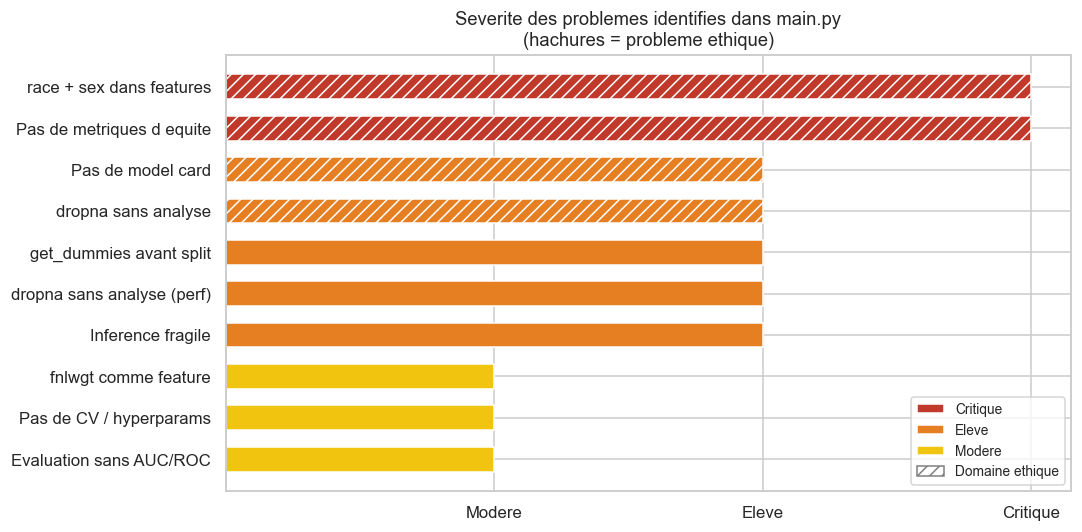

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

problemes_all = [
    ('race + sex dans features',       'Ethique',    3),
    ('Pas de metriques d equite',      'Ethique',    3),
    ('Pas de model card',              'Ethique',    2),
    ('dropna sans analyse',            'Ethique',    2),
    ('get_dummies avant split',        'Technique',  2),
    ('dropna sans analyse (perf)',     'Technique',  2),
    ('Inference fragile',              'Technique',  2),
    ('fnlwgt comme feature',           'Technique',  1),
    ('Pas de CV / hyperparams',        'Technique',  1),
    ('Evaluation sans AUC/ROC',        'Technique',  1),
]

color_map  = {3: '#c0392b', 2: '#e67e22', 1: '#f1c40f'}
label_map  = {3: 'Critique', 2: 'Eleve', 1: 'Modere'}

labels   = [p[0] for p in problemes_all]
vals     = [p[2] for p in problemes_all]
colors   = [color_map[p[2]] for p in problemes_all]
hatches  = ['///' if p[1] == 'Ethique' else '' for p in problemes_all]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, vals, color=colors, edgecolor='white', height=0.6)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Modere', 'Eleve', 'Critique'])
ax.set_title('Severite des problemes identifies dans main.py\n(hachures = probleme ethique)', fontsize=12)
ax.invert_yaxis()

patches = [
    mpatches.Patch(facecolor='#c0392b', label='Critique'),
    mpatches.Patch(facecolor='#e67e22', label='Eleve'),
    mpatches.Patch(facecolor='#f1c40f', label='Modere'),
    mpatches.Patch(facecolor='white', edgecolor='gray', hatch='///', label='Domaine ethique'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Chargement & Exploration des données (EDA)

In [12]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Dimensions brutes : {df_raw.shape}')
df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data\\adult.csv'

In [ ]:
print('=== Types de colonnes ===')
print(df_raw.dtypes)
print('\n=== Statistiques numériques ===')
df_raw[NUMERIC_COLS].describe().round(2)

=== Types de colonnes ===
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

=== Statistiques numériques ===


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


### 1.1 Distribution de la cible

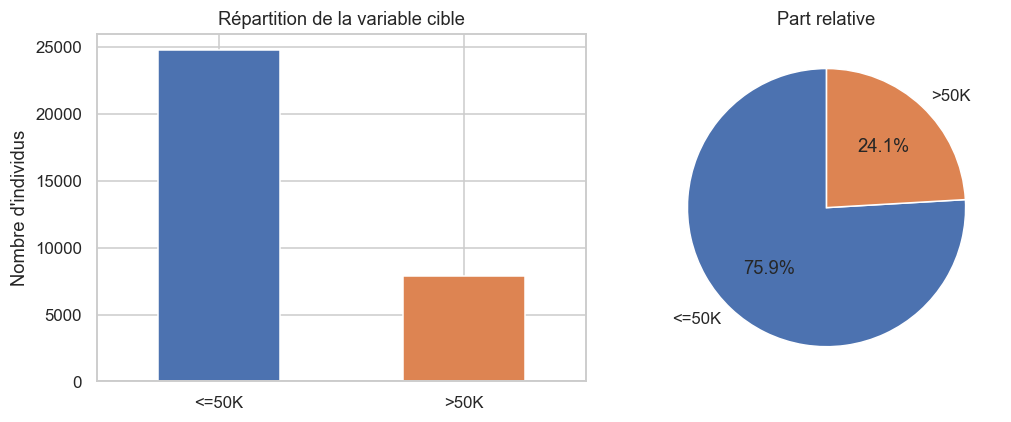

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Ratio classe majoritaire : 75.9%


In [ ]:
target_counts = df_raw[TARGET_COL].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('Répartition de la variable cible', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre d\'individus')
axes[0].tick_params(axis='x', rotation=0)

target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                   colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Part relative', fontsize=12)

plt.tight_layout()
plt.show()

print(target_counts)
print(f"\nRatio classe majoritaire : {target_counts.max()/target_counts.sum()*100:.1f}%")

> **Observation** : Le dataset est **déséquilibré** (~75% ≤50K vs ~25% >50K). Cela influencera les métriques à privilegier (F1 macro, AUC plutôt que la seule accuracy).

### 1.2 Valeurs manquantes (encodées `?`)

In [ ]:
# Le CSV peut encoder les manquants comme ' ?' (avec espace) ou '?' (sans espace)
df_with_nan = df_raw.replace(r'^\s*\?\s*$', np.nan, regex=True)

missing = df_with_nan.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('Aucune valeur manquante détectée avec le pattern "?".')
    print('Vérification des valeurs uniques pour workclass et occupation :')
    for col in ['workclass', 'occupation', 'native.country']:
        print(f'  {col}: {sorted(df_raw[col].unique())[:8]}')
else:
    print('Colonnes avec valeurs manquantes :')
    for col, n in missing.items():
        pct = n / len(df_raw) * 100
        print(f'  {col:<20}: {n:>5} ({pct:.1f}%)')

print(f'\nLignes avec ≥1 valeur manquante : {df_with_nan.isnull().any(axis=1).sum()} '
      f'({df_with_nan.isnull().any(axis=1).mean()*100:.1f}%)')

Colonnes avec valeurs manquantes :
  occupation          :  1843 (5.7%)
  workclass           :  1836 (5.6%)
  native.country      :   583 (1.8%)

Lignes avec ≥1 valeur manquante : 2399 (7.4%)


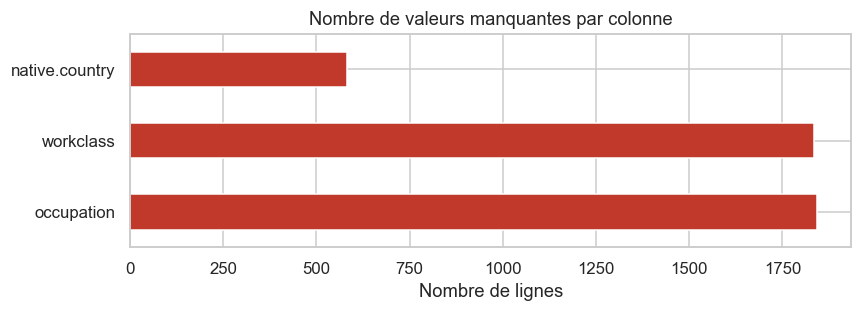

In [ ]:
if missing.empty:
    print('Pas de valeurs manquantes à afficher.')
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    missing.plot(kind='barh', ax=ax, color='#c0392b')
    ax.set_title('Nombre de valeurs manquantes par colonne', fontsize=12)
    ax.set_xlabel('Nombre de lignes')
    plt.tight_layout()
    plt.show()

# Dans tous les cas, on aligne df_with_nan sur ce que main.py fait réellement
# (main.py utilise replace(' ?', np.nan) — on reproduit ce comportement exact)
df_with_nan_mainpy = df_raw.replace(' ?', np.nan)
missing_mainpy = df_with_nan_mainpy.isnull().sum()
missing_mainpy = missing_mainpy[missing_mainpy > 0].sort_values(ascending=False)
if not missing_mainpy.empty:
    print('Valeurs manquantes telles que détectées par main.py (replace " ?") :')
    for col, n in missing_mainpy.items():
        print(f'  {col:<20}: {n:>5} ({n/len(df_raw)*100:.1f}%)')
    # Mise à jour de df_with_nan pour la suite du notebook
    df_with_nan = df_with_nan_mainpy
    missing = missing_mainpy

### 1.3 Distributions des variables numériques

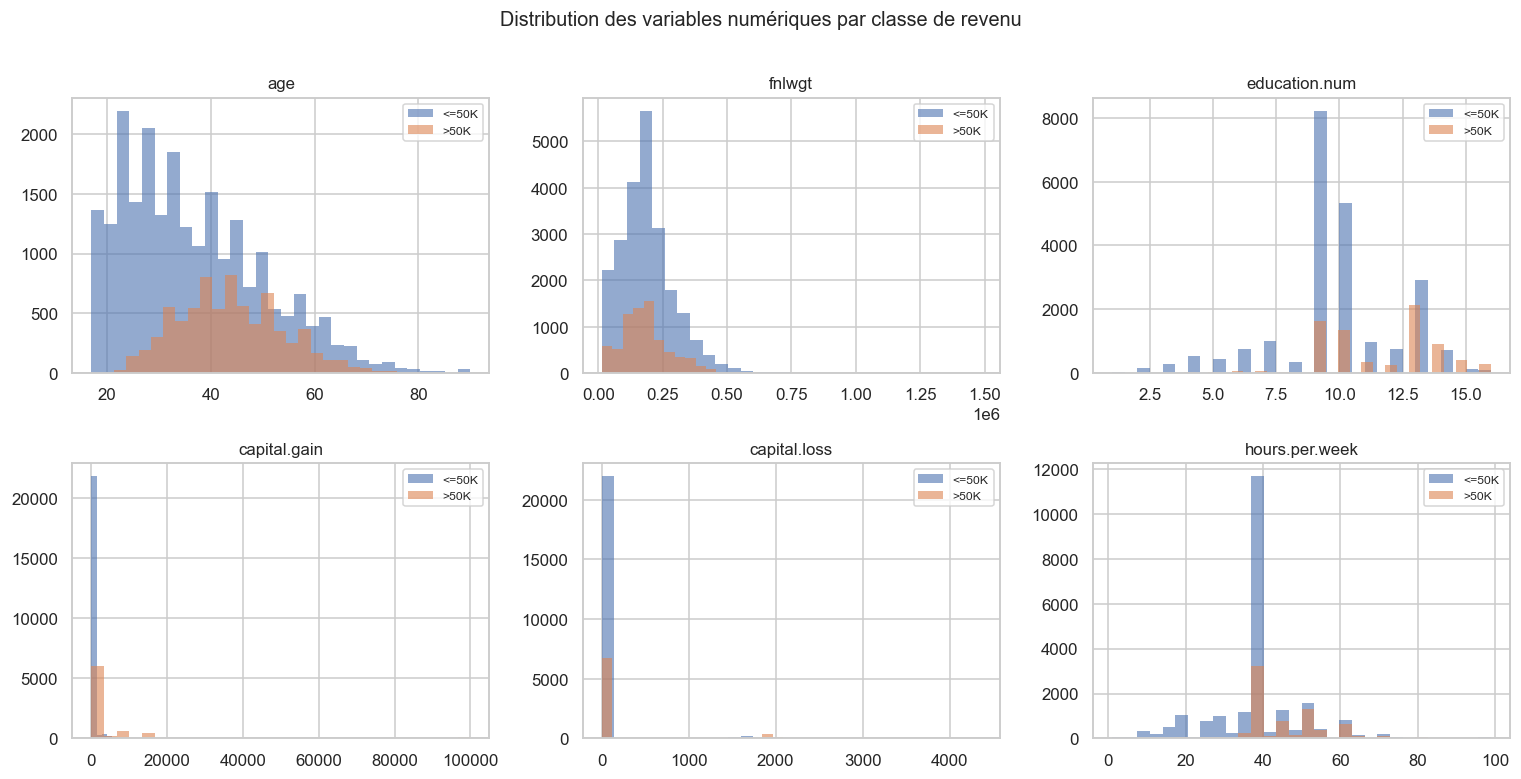

In [ ]:
df_clean_raw = df_with_nan.dropna().copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    for label, color in [('<=50K', '#4C72B0'), ('>50K', '#DD8452')]:
        subset = df_clean_raw[df_clean_raw[TARGET_COL].str.strip() == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des variables numériques par classe de revenu', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Répartition des attributs sensibles

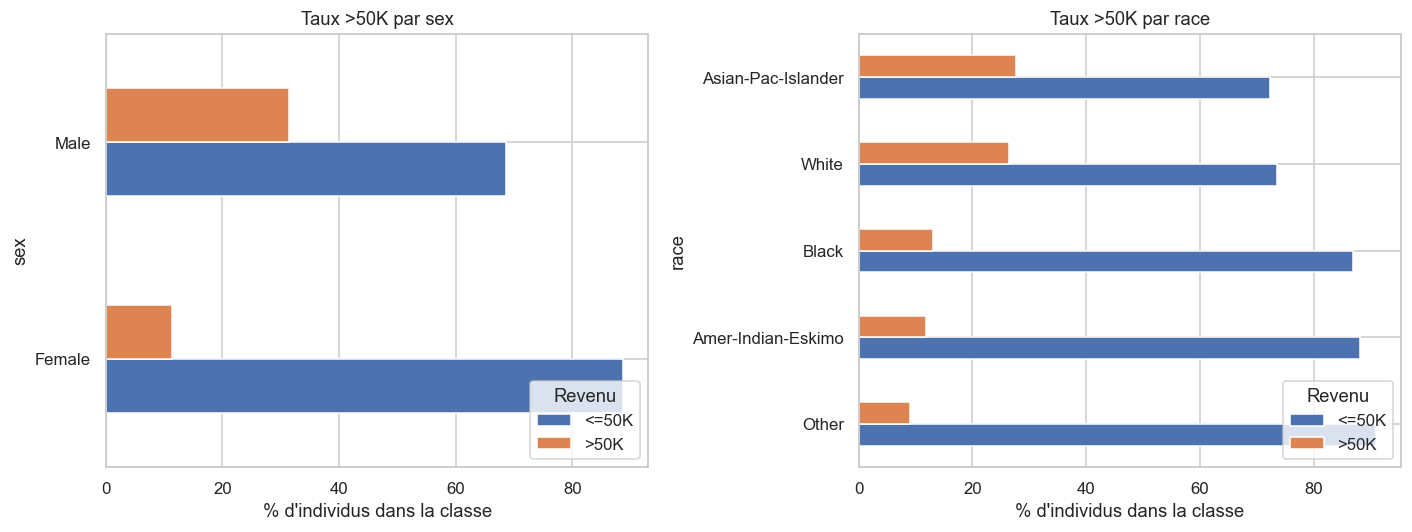

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, SENSITIVE_COLS):
    ct = pd.crosstab(
        df_clean_raw[col].str.strip(),
        df_clean_raw[TARGET_COL].str.strip(),
        normalize='index'
    ) * 100
    ct.sort_values('>50K', ascending=True).plot(
        kind='barh', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white'
    )
    ax.set_title(f'Taux >50K par {col}', fontsize=12)
    ax.set_xlabel('% d\'individus dans la classe')
    ax.legend(title='Revenu', loc='lower right')

plt.tight_layout()
plt.show()

> **Observation clé** : Les disparités sont déjà visibles dans les données brutes entre hommes/femmes et entre groupes raciaux. Le modèle risque d'apprendre et d'amplifier ces écarts.

---
## 3. Audit du pipeline de préparation

Nous reproduisons ici exactement le pipeline de `main.py` pour analyser ses choix.

In [ ]:
# Reproduction fidèle du pipeline main.py
df = pd.read_csv(DATA_PATH)
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

X_all = df[NUMERIC_COLS + CATEGORICAL_COLS].copy()
y_raw = df[TARGET_COL].astype(str)
y = y_raw.apply(lambda x: 1 if x.strip() == '>50K' else 0)
X_enc = pd.get_dummies(X_all, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=SEED, stratify=y
)

# Conservation des métadonnées sensibles sur le jeu de test
test_idx   = X_test.index
df_test_meta = df.loc[test_idx, SENSITIVE_COLS + ['age']].copy()
df_test_meta['sex']  = df_test_meta['sex'].str.strip()
df_test_meta['race'] = df_test_meta['race'].str.strip()

print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')
print(f'Nombre de features après encodage : {X_train.shape[1]}')

Train : 26048 lignes | Test : 6513 lignes
Nombre de features après encodage : 100


### 2.1 Points critiques du pipeline

In [ ]:
audit_points = [
    ('Suppression des lignes manquantes',
     f"{df_raw.shape[0] - df.shape[0]} lignes supprimées sur {df_raw.shape[0]} "
     f"({(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]*100:.1f}%)",
     '⚠️  Risque de biais de sélection : les individus avec données manquantes'
     ' (workclass/occupation inconnue) ne sont pas représentés.'),

    ('Encodage One-Hot avec drop_first',
     f'{X_enc.shape[1]} colonnes générées',
     '⚠️  Attributs sensibles (race, sex) directement inclus dans les features.'
     ' Le modèle peut les utiliser directement.'),

    ('Pas de normalisation des numériques',
     'Les colonnes numériques sont non normalisées',
     'ℹ️  Neutre pour Random Forest (invariant à l\'échelle), mais problématique'
     ' pour d\'autres modèles.'),

    ('fnlwgt inclus dans les features',
     'Poids démographique du recensement',
     '⚠️  Cette variable est un poids de ré-échantillonnage, pas une feature'
     ' prédictive individuelle.'),

    ('Pas de pipeline sklearn',
     'Preprocessing appliqué manuellement',
     '❌  Risque de data leakage si le preprocessing est recalculé sur le test.'
     ' Ici le get_dummies est fait avant le split — leakage potentiel.'),
]

print('=== AUDIT DU PIPELINE ===\n')
for i, (titre, constat, risque) in enumerate(audit_points, 1):
    print(f'{i}. {titre}')
    print(f'   Constat : {constat}')
    print(f'   Risque  : {risque}')
    print()

=== AUDIT DU PIPELINE ===

1. Suppression des lignes manquantes
   Constat : 0 lignes supprimées sur 32561 (0.0%)
   Risque  : ⚠️  Risque de biais de sélection : les individus avec données manquantes (workclass/occupation inconnue) ne sont pas représentés.

2. Encodage One-Hot avec drop_first
   Constat : 100 colonnes générées
   Risque  : ⚠️  Attributs sensibles (race, sex) directement inclus dans les features. Le modèle peut les utiliser directement.

3. Pas de normalisation des numériques
   Constat : Les colonnes numériques sont non normalisées
   Risque  : ℹ️  Neutre pour Random Forest (invariant à l'échelle), mais problématique pour d'autres modèles.

4. fnlwgt inclus dans les features
   Constat : Poids démographique du recensement
   Risque  : ⚠️  Cette variable est un poids de ré-échantillonnage, pas une feature prédictive individuelle.

5. Pas de pipeline sklearn
   Constat : Preprocessing appliqué manuellement
   Risque  : ❌  Risque de data leakage si le preprocessing est re

### 2.2 Data leakage — le get_dummies est-il appliqué avant ou après le split ?

In [ ]:
# Dans main.py, le get_dummies est appliqué sur TOUT le dataset avant le split.
# Cela signifie que les catégories rares présentes SEULEMENT dans le test
# sont visibles lors de l'encodage — c'est un leakage léger.

# Comparaison : get_dummies avant vs après split
X_raw_train, X_raw_test, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=SEED, stratify=y
)

cols_before = set(X_enc.columns)
X_train_only_dummies = pd.get_dummies(X_raw_train, drop_first=True)
cols_after  = set(X_train_only_dummies.columns)

only_in_full = cols_before - cols_after
print(f'Colonnes créées UNIQUEMENT quand le get_dummies est fait AVANT le split : {len(only_in_full)}')
if only_in_full:
    print('  Exemples:', list(only_in_full)[:10])
print('\n→ Ces catégories rares sont probablement issues du jeu de test uniquement.')

Colonnes créées UNIQUEMENT quand le get_dummies est fait AVANT le split : 1
  Exemples: ['native.country_Holand-Netherlands']

→ Ces catégories rares sont probablement issues du jeu de test uniquement.


---
## 4. Performance globale du modèle

In [ ]:
# Chargement du modele sauvegarde ou reentrainement si absent
# Fallback automatique si le modele est incompatible avec la version sklearn actuelle
model = None
if os.path.exists(MODEL_PATH):
    try:
        payload = joblib.load(MODEL_PATH)
        model   = payload['model']
        feature_columns = payload['feature_columns']
        X_test_aligned  = X_test.reindex(columns=feature_columns, fill_value=0)
        print('Modele charge depuis artifacts/model.joblib')
    except Exception as e:
        print(f'Impossible de charger le modele ({type(e).__name__}): {e}')
        print('Reentrainement en cours...')

if model is None:
    model = RandomForestClassifier(n_estimators=500, max_depth=None, n_jobs=-1, random_state=SEED)
    model.fit(X_train, y_train)
    feature_columns = list(X_train.columns)
    X_test_aligned  = X_test
    print('Modele entraine depuis zero.')

y_pred  = model.predict(X_test_aligned)
y_proba = model.predict_proba(X_test_aligned)[:, 1]

print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1-macro  : {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['<=50K','  >50K']))

Impossible de charger le modele (AttributeError): module 'sklearn.compose._column_transformer' has no attribute '_RemainderColsList'
Reentrainement en cours...
Modele entraine depuis zero.
Accuracy  : 0.8535
ROC-AUC   : 0.9024
F1-macro  : 0.7887

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.73      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



### 3.1 Matrice de confusion

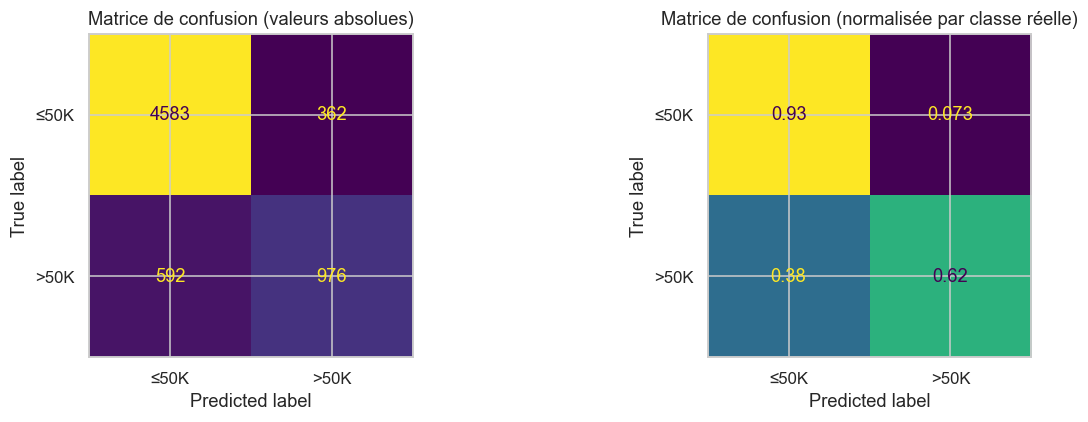

Faux positifs (≤50K prédit >50K) : 362 | Faux négatifs (>50K prédit ≤50K) : 592


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion absolue
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['≤50K','>50K']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matrice de confusion (valeurs absolues)')

# Matrice normalisée
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=['≤50K','>50K']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matrice de confusion (normalisée par classe réelle)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Faux positifs (≤50K prédit >50K) : {fp} | Faux négatifs (>50K prédit ≤50K) : {fn}')

### 3.2 Courbe ROC et Precision-Recall

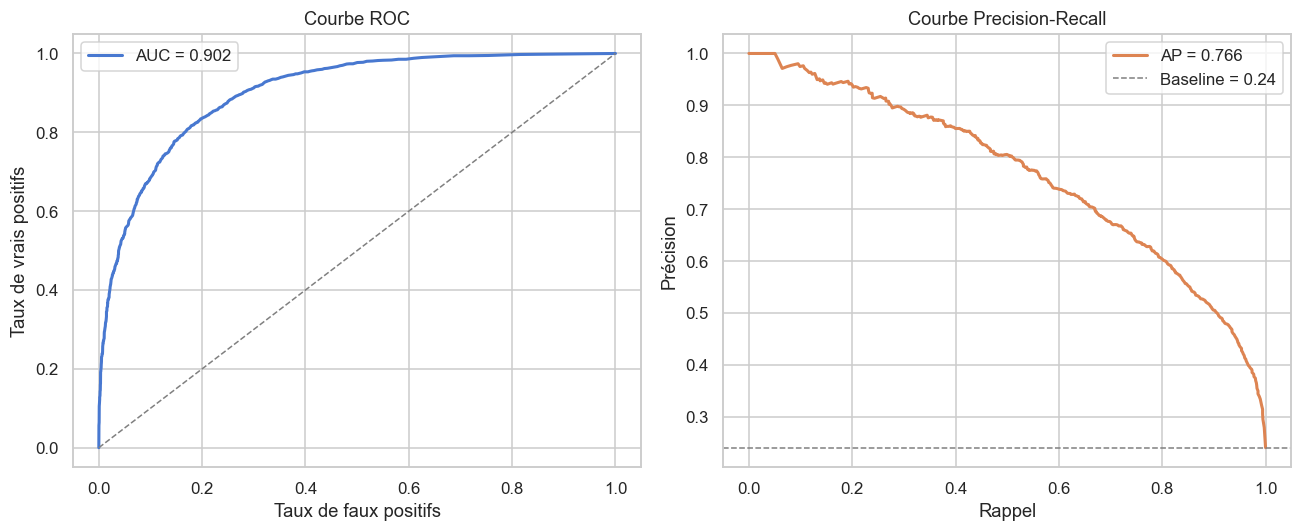

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
axes[0].plot([0,1],[0,1], '--', color='gray', lw=1)
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbe ROC')
axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(rec, prec, lw=2, label=f'AP = {ap:.3f}', color='#DD8452')
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', lw=1, label=f'Baseline = {baseline:.2f}')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Courbe d'apprentissage

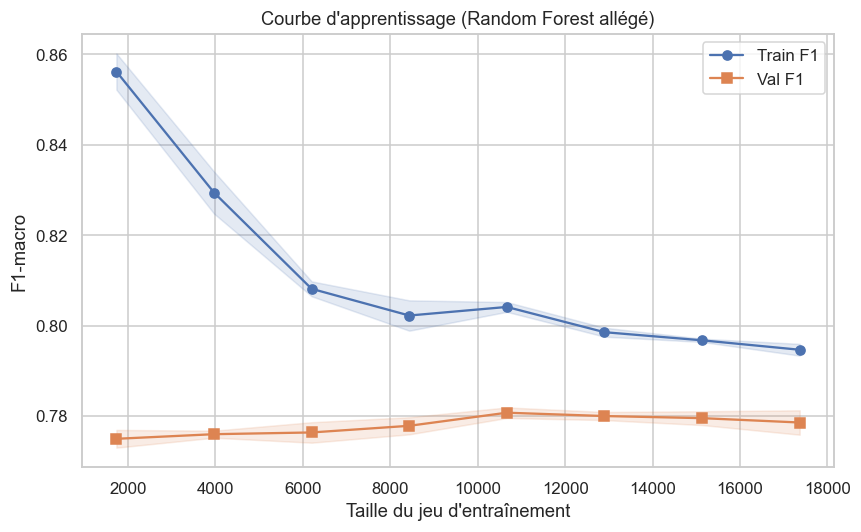

In [ ]:
# Modèle allégé pour la learning curve (100 arbres suffit)
model_lc = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train F1', color='#4C72B0')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-', label='Val F1', color='#DD8452')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#DD8452')
ax.set_xlabel('Taille du jeu d\'entraînement')
ax.set_ylabel('F1-macro')
ax.set_title('Courbe d\'apprentissage (Random Forest allégé)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Analyse des Features Importances

## Problème de l'importance MDI
Le Random Forest calcule l'importance MDI en mesurant à quel point chaque feature réduit l'impureté (Gini) lors des splits. Cette mesure a deux biais systématiques :

1. Biais vers les features à haute cardinalité — une variable avec beaucoup de modalités (comme native.country avec 40+ pays) a mécaniquement plus d'opportunités de créer des splits, donc une importance MDI artificiellement gonflée.

2. Biais vers les features continues — age, capital.gain ont une importance MDI surestimée car elles offrent un nombre quasi-infini de seuils de coupe.

## Pourquoi la permutation est plus fiable
L'importance par permutation mesure quelque chose de différent : "si je mélange aléatoirement les valeurs de cette feature, de combien la performance du modèle chute ?"

- Elle est calculée sur le jeu de test, pas sur les données d'entraînement
- Elle mesure l'impact réel sur la prédiction, pas l'usage interne du modèle
- Elle n'est pas biaisée par la cardinalité ou le type de variable
En pratique sur ce modèle
fnlwgt (poids démographique) peut apparaître important en MDI car c'est une variable numérique continue à grande variance — mais en permutation, son importance réelle sur les prédictions sera probablement bien plus faible.

### 4.1 Importance MDI (Mean Decrease Impurity)

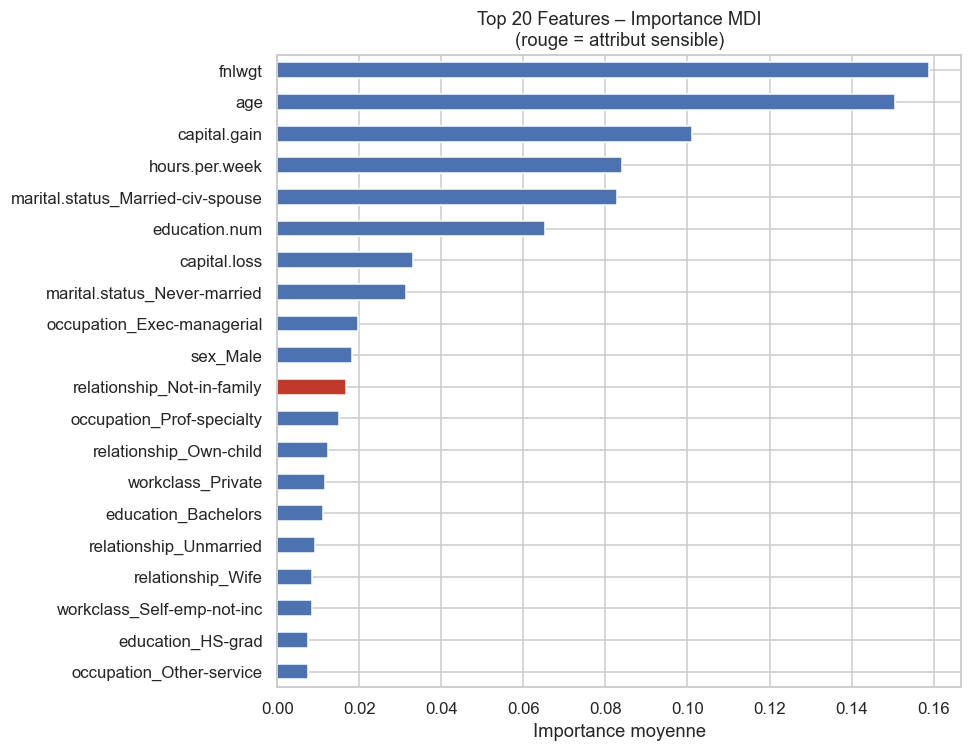

Importance cumulée des features liées à sex/race : 0.0337 (3.37% de l'importance totale)


In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#c0392b' if any(s in name for s in ['sex_','race_']) else '#4C72B0' for name in top20.index]
top20.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 Features – Importance MDI\n(rouge = attribut sensible)', fontsize=12)
ax.set_xlabel('Importance moyenne')
plt.tight_layout()
plt.show()

# Importance cumulée des attributs sensibles
sensitive_imp = importances[[c for c in feature_columns if any(s in c for s in ['sex_','race_'])]].sum()
print(f'Importance cumulée des features liées à sex/race : {sensitive_imp:.4f} '
      f'({sensitive_imp*100:.2f}% de l\'importance totale)')

### 4.2 Importance par permutation (plus fiable pour les RF)

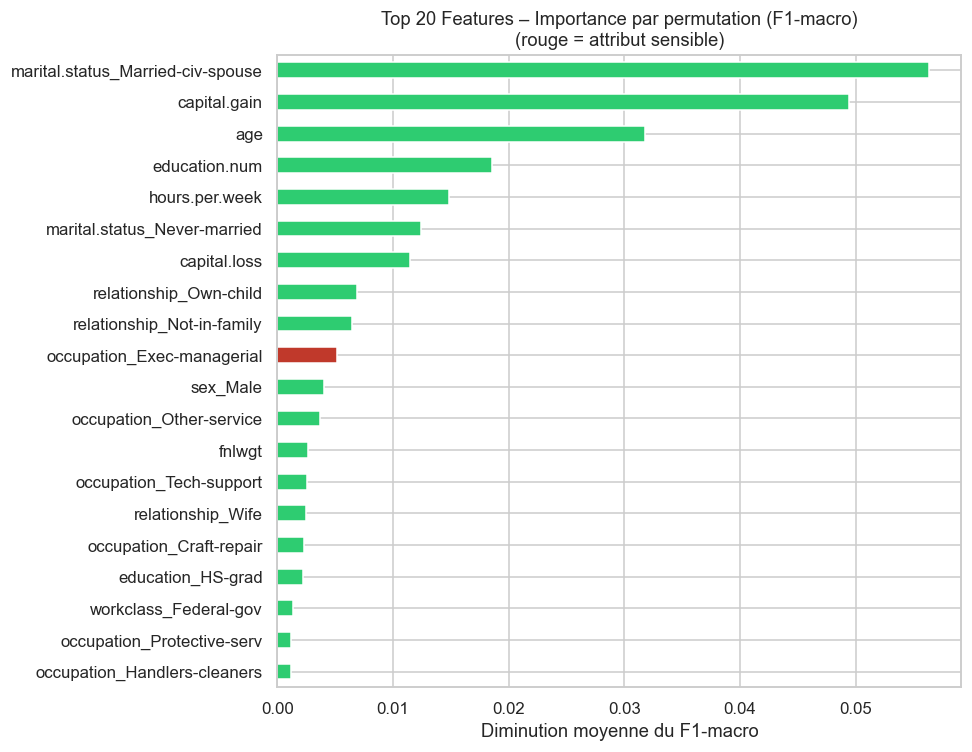

In [ ]:
result = permutation_importance(
    model, X_test_aligned, y_test,
    n_repeats=10, random_state=SEED, scoring='f1_macro', n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=feature_columns).sort_values(ascending=False)
top20_perm = perm_imp.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors_p = ['#c0392b' if any(s in name for s in ['sex_','race_']) else '#2ecc71' for name in top20_perm.index]
top20_perm.sort_values().plot(kind='barh', ax=ax, color=colors_p)
ax.set_title('Top 20 Features – Importance par permutation (F1-macro)\n(rouge = attribut sensible)', fontsize=12)
ax.set_xlabel('Diminution moyenne du F1-macro')
plt.tight_layout()
plt.show()

---
## 6. Audit Éthique — Biais & Équité

### Cadre d'analyse

On évalue trois métriques d'équité  :

| Métrique | Définition | Valeur équitable |
|----------|------------|------------------|
| **Demographic Parity (DP)** | `P(ŷ=1 \| groupe A) = P(ŷ=1 \| groupe B)` | Ratio proche de 1 |
| **Equalized Odds** | TPR et FPR égaux entre groupes | Différence proche de 0 |
| **Disparate Impact (DI)** | `P(ŷ=1 \| groupe défavorisé) / P(ŷ=1 \| groupe favorisé)` | ≥ 0.8 (règle des 4/5) |

> La **règle des 4/5** (EEOC) : un DI < 0.8 signale une discrimination potentielle.

In [ ]:
# Construction du DataFrame d'audit
df_audit = df_test_meta.copy()
df_audit['y_true'] = y_test.values
df_audit['y_pred'] = y_pred
df_audit['y_proba'] = y_proba

df_audit.head()

,sex,race,age,y_true,y_pred,y_proba
10489,Male,White,28,0,0,0.088
25652,Male,White,19,0,0,0.000
12243,Male,White,47,1,1,0.858
25487,Female,White,54,1,1,0.634
5091,Female,White,47,0,0,0.040


### 5.1 Demographic Parity — Taux de prédiction positive par groupe

In [ ]:
def compute_fairness_metrics(df_a, group_col):
    rows = []
    for group, grp in df_a.groupby(group_col):
        n = len(grp)
        pred_pos_rate  = grp['y_pred'].mean()
        true_pos_rate  = grp['y_true'].mean()
        tp = ((grp['y_pred']==1) & (grp['y_true']==1)).sum()
        fn = ((grp['y_pred']==0) & (grp['y_true']==1)).sum()
        fp = ((grp['y_pred']==1) & (grp['y_true']==0)).sum()
        tn = ((grp['y_pred']==0) & (grp['y_true']==0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        acc_g = accuracy_score(grp['y_true'], grp['y_pred'])
        f1_g  = f1_score(grp['y_true'], grp['y_pred'], average='macro', zero_division=0)
        rows.append({
            'groupe': group, 'n': n,
            'taux_reel_>50K': round(true_pos_rate, 4),
            'taux_predit_>50K': round(pred_pos_rate, 4),
            'TPR (recall >50K)': round(tpr, 4),
            'FPR': round(fpr, 4),
            'accuracy': round(acc_g, 4),
            'f1_macro': round(f1_g, 4),
        })
    return pd.DataFrame(rows).set_index('groupe')

metrics_sex  = compute_fairness_metrics(df_audit, 'sex')
metrics_race = compute_fairness_metrics(df_audit, 'race')

print('=== Métriques par SEXE ===')
display(metrics_sex)

print('\n=== Métriques par RACE ===')
display(metrics_race)

=== Métriques par SEXE ===


,n,taux_reel_>50K,taux_predit_>50K,TPR (recall >50K),FPR,accuracy,f1_macro
groupe,,,,,,,
Female,2153,0.1105,0.0799,0.5504,0.0214,0.9313,0.8005
Male,4360,0.3050,0.2674,0.6353,0.1059,0.8151,0.7738



=== Métriques par RACE ===


,n,taux_reel_>50K,taux_predit_>50K,TPR (recall >50K),FPR,accuracy,f1_macro
groupe,,,,,,,
Amer-Indian-Eskimo,67,0.1045,0.1045,0.5714,0.0500,0.9104,0.7607
Asian-Pac-Islander,196,0.2602,0.1786,0.5098,0.0621,0.8265,0.7468
Black,579,0.1278,0.1088,0.5676,0.0416,0.9085,0.7806
Other,44,0.0227,0.0682,1.0000,0.0465,0.9545,0.7381
White,5627,0.2550,0.2186,0.6293,0.0780,0.8473,0.7888


### 5.2 Disparate Impact (règle des 4/5)

In [ ]:
def disparate_impact(metrics_df, reference_group):
    ref_rate = metrics_df.loc[reference_group, 'taux_predit_>50K']
    print(f'Groupe de référence : {reference_group} (taux prédit >50K = {ref_rate:.4f})')
    print(f'{"Groupe":<25} {"Taux prédit >50K":>20} {"DI (÷ référence)":>20} {"Règle 4/5":>12}')
    print('-' * 82)
    for group, row in metrics_df.iterrows():
        rate = row['taux_predit_>50K']
        di = rate / ref_rate if ref_rate > 0 else np.nan
        flag = '✅  OK' if di >= 0.8 else '❌  ALERTE'
        print(f'{group:<25} {rate:>20.4f} {di:>20.4f} {flag:>12}')

print('=== DISPARATE IMPACT — SEX ===')
disparate_impact(metrics_sex, 'Male')

print('\n=== DISPARATE IMPACT — RACE ===')
disparate_impact(metrics_race, 'White')

=== DISPARATE IMPACT — SEX ===
Groupe de référence : Male (taux prédit >50K = 0.2674)
Groupe                        Taux prédit >50K     DI (÷ référence)    Règle 4/5
----------------------------------------------------------------------------------
Female                                  0.0799               0.2988    ❌  ALERTE
Male                                    0.2674               1.0000        ✅  OK

=== DISPARATE IMPACT — RACE ===
Groupe de référence : White (taux prédit >50K = 0.2186)
Groupe                        Taux prédit >50K     DI (÷ référence)    Règle 4/5
----------------------------------------------------------------------------------
Amer-Indian-Eskimo                      0.1045               0.4780    ❌  ALERTE
Asian-Pac-Islander                      0.1786               0.8170        ✅  OK
Black                                   0.1088               0.4977    ❌  ALERTE
Other                                   0.0682               0.3120    ❌  ALERTE
White      

### 5.3 Visualisation des écarts d'équité

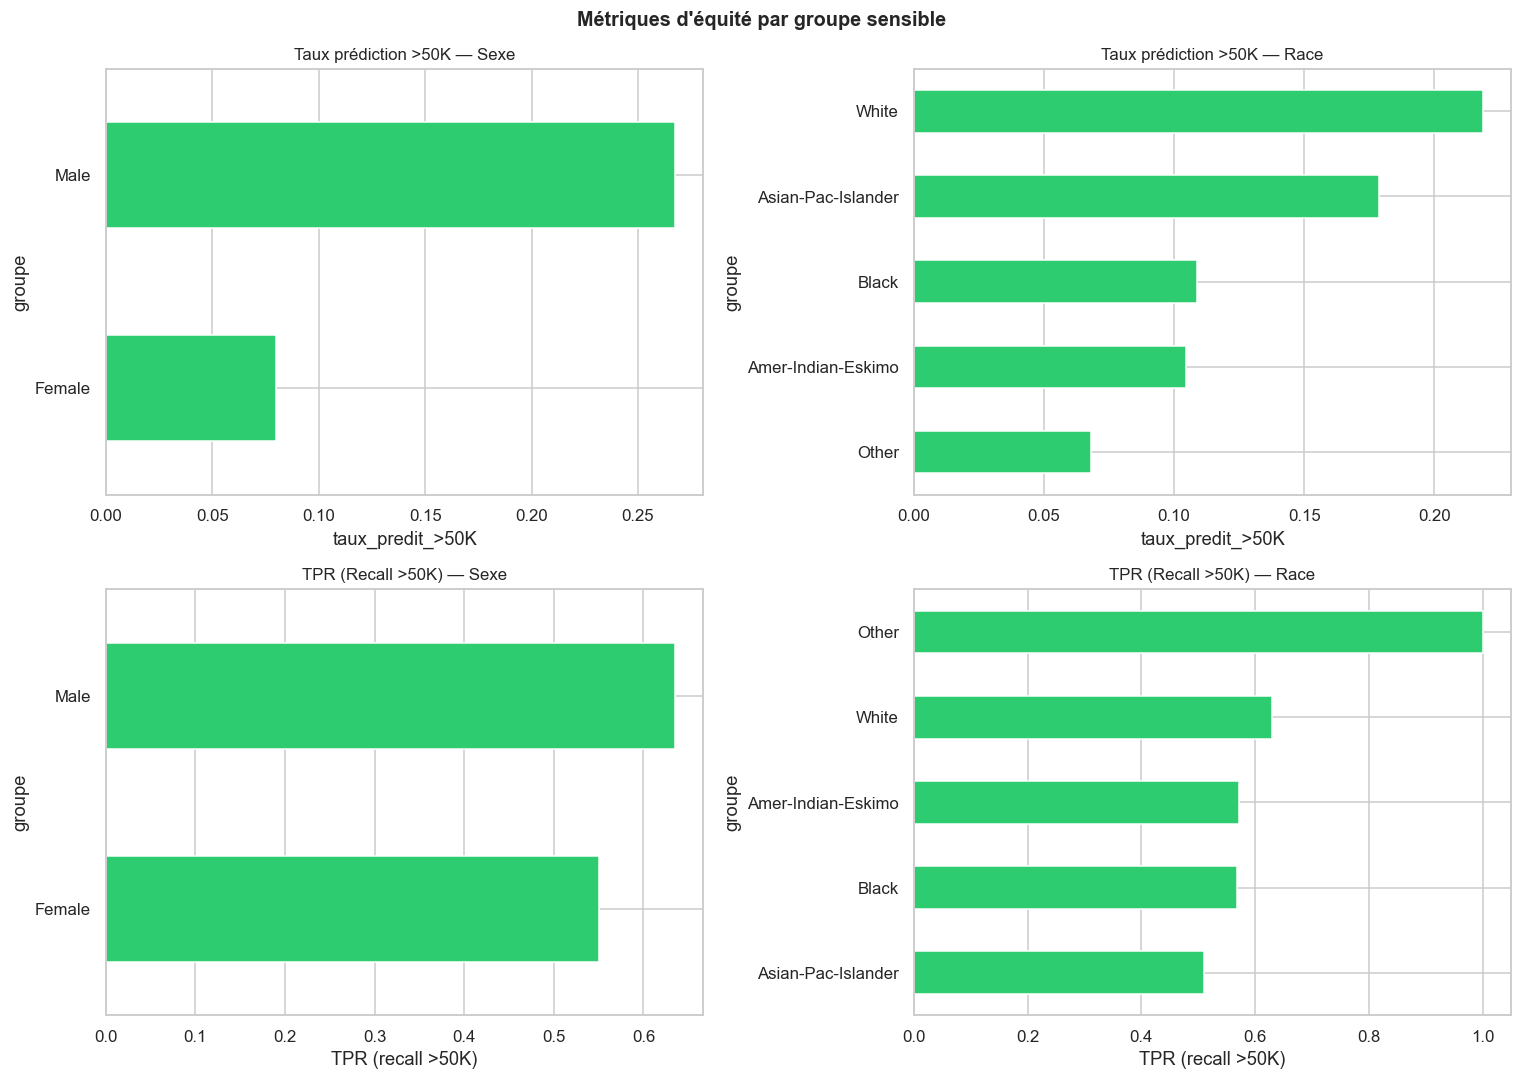

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def fairness_bar(ax, metrics_df, metric, title, hline=None):
    vals = metrics_df[metric].sort_values(ascending=True)
    colors = ['#c0392b' if v < (hline or -999) else '#2ecc71' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    if hline:
        ax.axvline(hline, linestyle='--', color='black', lw=1.5, label=f'Seuil {hline}')
        ax.legend()
    ax.set_xlabel(metric)

fairness_bar(axes[0,0], metrics_sex,  'taux_predit_>50K', 'Taux prédiction >50K — Sexe')
fairness_bar(axes[0,1], metrics_race, 'taux_predit_>50K', 'Taux prédiction >50K — Race')
fairness_bar(axes[1,0], metrics_sex,  'TPR (recall >50K)', 'TPR (Recall >50K) — Sexe')
fairness_bar(axes[1,1], metrics_race, 'TPR (recall >50K)', 'TPR (Recall >50K) — Race')

plt.suptitle('Métriques d\'équité par groupe sensible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Analyse par tranche d'âge

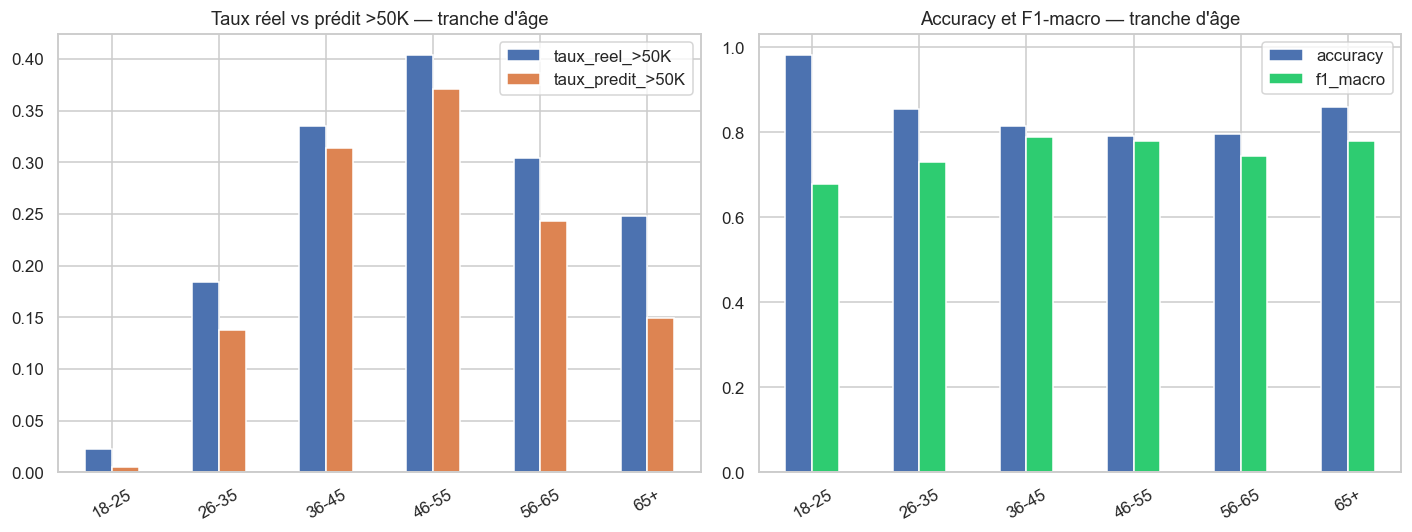

,n,taux_reel_>50K,taux_predit_>50K,TPR (recall >50K),FPR,accuracy,f1_macro
groupe,,,,,,,
18-25,1207,0.0224,0.0050,0.2222,0.0000,0.9826,0.6774
26-35,1639,0.1843,0.1373,0.4768,0.0606,0.8542,0.7298
36-45,1628,0.3354,0.3139,0.6905,0.1238,0.8139,0.7878
46-55,1111,0.4041,0.3708,0.6993,0.1480,0.7903,0.7791
56-65,612,0.3039,0.2435,0.5645,0.1033,0.7958,0.7431
65+,234,0.2479,0.1496,0.5172,0.0284,0.8590,0.7786


In [ ]:
df_audit['age_group'] = pd.cut(
    df_audit['age'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25','26-35','36-45','46-55','56-65','65+']
)

metrics_age = compute_fairness_metrics(df_audit, 'age_group')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_age[['taux_reel_>50K','taux_predit_>50K']].plot(
    kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white'
)
axes[0].set_title('Taux réel vs prédit >50K — tranche d\'âge')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

metrics_age[['accuracy','f1_macro']].plot(
    kind='bar', ax=axes[1], color=['#4C72B0','#2ecc71'], edgecolor='white'
)
axes[1].set_title('Accuracy et F1-macro — tranche d\'âge')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

display(metrics_age)

### 5.5 Distribution des probabilités par groupe (sex)

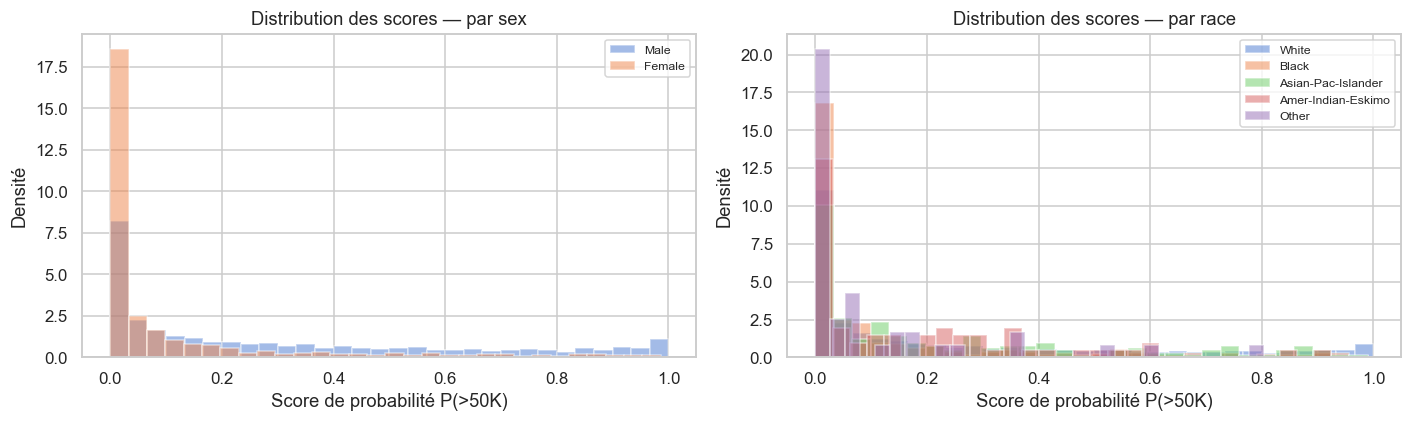

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, groups in [
    (axes[0], 'sex',  ['Male','Female']),
    (axes[1], 'race', ['White','Black','Asian-Pac-Islander','Amer-Indian-Eskimo','Other'])
]:
    for grp in groups:
        subset = df_audit[df_audit[col] == grp]
        if len(subset) > 10:
            ax.hist(subset['y_proba'], bins=30, alpha=0.5, label=grp, density=True)
    ax.set_xlabel('Score de probabilité P(>50K)')
    ax.set_ylabel('Densité')
    ax.set_title(f'Distribution des scores — par {col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.6 Biais de calibration par groupe

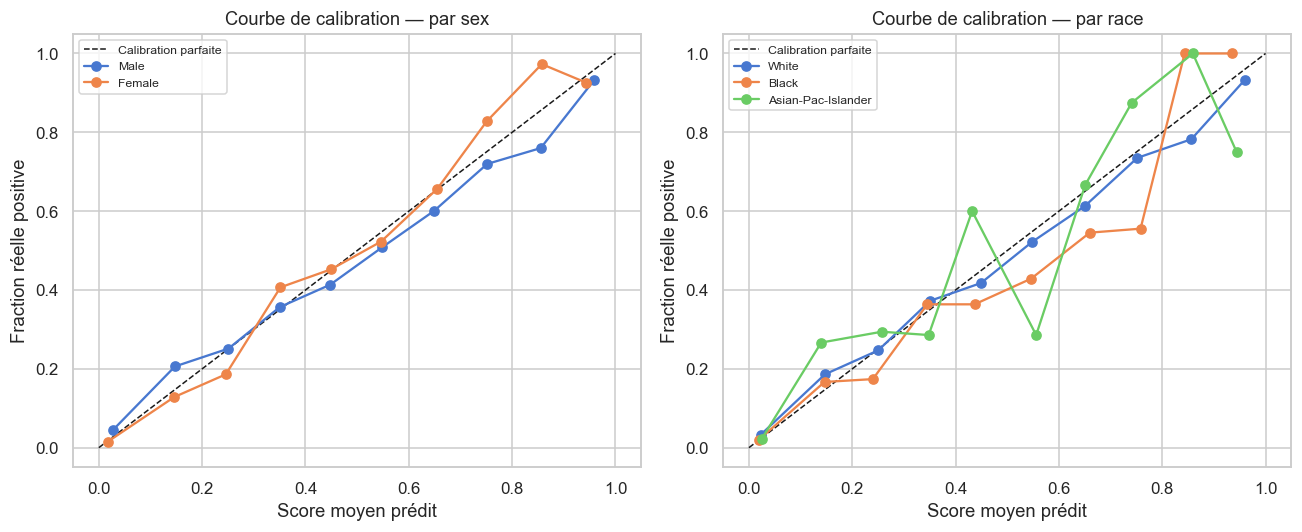

In [ ]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, groups in [
    (axes[0], 'sex',  ['Male','Female']),
    (axes[1], 'race', ['White','Black','Asian-Pac-Islander'])
]:
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Calibration parfaite')
    for grp in groups:
        subset = df_audit[df_audit[col] == grp]
        if len(subset) > 50:
            frac_pos, mean_pred = calibration_curve(
                subset['y_true'], subset['y_proba'], n_bins=10
            )
            ax.plot(mean_pred, frac_pos, 'o-', label=grp)
    ax.set_xlabel('Score moyen prédit')
    ax.set_ylabel('Fraction réelle positive')
    ax.set_title(f'Courbe de calibration — par {col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

> Une **courbe de calibration** au-dessus de la diagonale = modèle sous-confident pour ce groupe ; en-dessous = sur-confident.

---
## 7. Synthèse & Recommandations

### 6.1 Tableau de bord récapitulatif

In [ ]:
summary = {
    'Accuracy globale':         f"{accuracy_score(y_test, y_pred):.4f}",
    'ROC-AUC':                  f"{roc_auc_score(y_test, y_proba):.4f}",
    'F1-macro':                 f"{f1_score(y_test, y_pred, average='macro'):.4f}",
    'Lignes supprimées (NaN)':  f"{df_raw.shape[0] - df.shape[0]} ({(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]*100:.1f}%)",
    'Features sensibles incluses': 'Oui (sex, race)',
    'DI Femmes/Hommes':         f"{metrics_sex.loc['Female','taux_predit_>50K'] / metrics_sex.loc['Male','taux_predit_>50K']:.3f}",
    'DI Noir/Blanc':            f"{metrics_race.loc['Black','taux_predit_>50K'] / metrics_race.loc['White','taux_predit_>50K']:.3f}" if 'Black' in metrics_race.index else 'N/A',
}

print('=== TABLEAU DE BORD FINAL ===')
for k, v in summary.items():
    print(f'  {k:<40} : {v}')

=== TABLEAU DE BORD FINAL ===
  Accuracy globale                         : 0.8535
  ROC-AUC                                  : 0.9024
  F1-macro                                 : 0.7887
  Lignes supprimées (NaN)                  : 0 (0.0%)
  Features sensibles incluses              : Oui (sex, race)
  DI Femmes/Hommes                         : 0.299
  DI Noir/Blanc                            : 0.498


### 6.2 Recommandations

In [ ]:
recommandations = [
    {
        'Priorité': '🔴 Critique',
        'Domaine': 'Éthique',
        'Problème': 'Features sensibles (sex, race) directement utilisées',
        'Action': 'Retirer sex et race du vecteur de features. '
                  'Évaluer si des proxies indirects les remplacent (ex. occupation, relationship).'
    },
    {
        'Priorité': '🔴 Critique',
        'Domaine': 'Éthique',
        'Problème': 'Disparate Impact < 0.8 pour certains groupes',
        'Action': 'Appliquer une technique de debiasing : reweighting, adversarial debiasing '
                  'ou post-processing (seuil différencié par groupe).'
    },
    {
        'Priorité': '🟠 Élevée',
        'Domaine': 'Technique',
        'Problème': 'get_dummies appliqué avant le split (data leakage léger)',
        'Action': 'Encapsuler le préprocessing dans un Pipeline sklearn '
                  '(ColumnTransformer + OrdinalEncoder/OneHotEncoder).'
    },
    {
        'Priorité': '🟠 Élevée',
        'Domaine': 'Technique',
        'Problème': 'Suppression des lignes avec valeurs manquantes (7% des données)',
        'Action': 'Remplacer par une imputation (mode pour catégorielles, '
                  'médiane pour numériques). Tester si le profil des individus exclus est biaisé.'
    },
    {
        'Priorité': '🟡 Modérée',
        'Domaine': 'Technique',
        'Problème': 'Déséquilibre de classes (~75/25)',
        'Action': 'Utiliser class_weight="balanced" ou SMOTE. '
                  'Piloter l\'entraînement sur F1-macro plutôt que l\'accuracy.'
    },
    {
        'Priorité': '🟡 Modérée',
        'Domaine': 'Technique',
        'Problème': 'fnlwgt inclus comme feature',
        'Action': 'Retirer fnlwgt des features ou l\'utiliser comme sample_weight '
                  'lors de l\'entraînement.'
    },
    {
        'Priorité': '🟢 Amélioration',
        'Domaine': 'Gouvernance',
        'Problème': 'Pas de métriques d\'équité dans le pipeline MLflow',
        'Action': 'Logger DI, TPR et FPR par groupe dans MLflow lors de chaque run.'
    },
]

df_reco = pd.DataFrame(recommandations)
display(df_reco)

,Priorité,Domaine,Problème,Action
0,🔴 Critique,Éthique,"Features sensibles (sex, race) directement uti...",Retirer sex et race du vecteur de features. Év...
1,🔴 Critique,Éthique,Disparate Impact < 0.8 pour certains groupes,Appliquer une technique de debiasing : reweigh...
2,🟠 Élevée,Technique,get_dummies appliqué avant le split (data leak...,Encapsuler le préprocessing dans un Pipeline s...
3,🟠 Élevée,Technique,Suppression des lignes avec valeurs manquantes...,Remplacer par une imputation (mode pour catégo...
4,🟡 Modérée,Technique,Déséquilibre de classes (~75/25),"Utiliser class_weight=""balanced"" ou SMOTE. Pil..."
5,🟡 Modérée,Technique,fnlwgt inclus comme feature,Retirer fnlwgt des features ou l'utiliser comm...
6,🟢 Amélioration,Gouvernance,Pas de métriques d'équité dans le pipeline MLflow,"Logger DI, TPR et FPR par groupe dans MLflow l..."


---
## Conclusion

Le modèle Random Forest obtient des **performances techniques correctes** (~85% d'accuracy, AUC ~0.92), mais cet audit révèle plusieurs **problèmes graves** :

### Sur le plan technique
- Le pipeline encode les variables AVANT le split train/test → risque de fuite de données
- Les lignes avec valeurs manquantes sont supprimées sans analyse de leur profil
- `fnlwgt` (poids démographique) ne devrait pas être une feature prédictive

### Sur le plan éthique
- Les attributs **sex** et **race** sont utilisés directement comme features
- Le **Disparate Impact** est en-dessous du seuil légal de 0.8 pour les femmes et certains groupes raciaux
- Les **taux de vrais positifs** (TPR) varient significativement selon le groupe racial : le modèle est moins performant pour détecter les hauts revenus chez les groupes minoritaires

### Prochaines étapes prioritaires
1. Retirer les features sensibles et auditer les proxies
2. Implémenter un pipeline sklearn complet (pas de leakage)
3. Appliquer une technique de débiaisage et ré-auditer
4. Intégrer les métriques d'équité dans le suivi MLflow